<a href="https://colab.research.google.com/github/anelriera/ibex_data/blob/main/mongosdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IBEX 35 Financial Data Pipeline to MongoDB Atlas

This notebook demonstrates how to scrape real-time financial data for IBEX 35 companies from Yahoo Finance, calculate various metrics, and store this data as daily snapshots in MongoDB Atlas. It also includes examples of querying the stored data and basic visualizations.

## Security Note for `MONGO_URI`

**IMPORTANT:** Never hardcode your `MONGO_URI` (MongoDB connection string) directly into your notebook. This is a security risk.

In Google Colab, the recommended way to handle sensitive information like API keys or connection strings is by using **Colab Secrets**.

1.  **Open the Secrets Panel:** On the left sidebar of your Colab notebook, click the '🔑' (Secrets) icon.
2.  **Add a New Secret:** Click '+ New secret' and add a new secret with the name `MONGO_URI` and paste your MongoDB Atlas connection string as its value.
3.  **Enable Notebook Access:** Make sure the 'Notebook access' toggle is turned ON for the `MONGO_URI` secret in your current notebook.

This notebook will then securely access `MONGO_URI` using `from google.colab import userdata`.

## 1. Install and Import Dependencies

First, we need to install the necessary Python libraries: `pymongo` for MongoDB interaction, `yfinance` for fetching financial data, `pandas` for data manipulation, and `python-dotenv` (though we'll use Colab's `userdata` for `MONGO_URI` directly, `python-dotenv` is good practice for local development).

After installation, we'll import these libraries and securely load the `MONGO_URI`.

In [ ]:
# Install necessary libraries
!pip install pymongo yfinance pandas python-dotenv

import os
import datetime
import pandas as pd
import yfinance as yf
from pymongo import MongoClient
from google.colab import userdata # For securely loading MONGO_URI in Colab

# Load MongoDB connection string from Colab secrets
MONGO_URI = userdata.get('MONGO_URI')

# Verify that the MONGO_URI is loaded (it should not print the actual URI for security)
if MONGO_URI:
    print("MONGO_URI loaded successfully from Colab Secrets.")
else:
    print("ERROR: MONGO_URI not found. Please add it to Colab Secrets.")

## 2. Connect to MongoDB Atlas

We will establish a connection to our MongoDB Atlas cluster using the `pymongo` library and the `MONGO_URI` loaded in the previous step. We'll then specify the database (`ibex_db`) and the collection (`daily_snapshots`) where our financial data will be stored.

In [2]:
# Connect to MongoDB Atlas
try:
    client = MongoClient(MONGO_URI)
    db = client.ibex_db
    collection = db.daily_snapshots
    print("Successfully connected to MongoDB Atlas and selected 'ibex_db' database and 'daily_snapshots' collection.")
except Exception as e:
    print(f"Error connecting to MongoDB: {e}")

Successfully connected to MongoDB Atlas and selected 'ibex_db' database and 'daily_snapshots' collection.


## 3. Extract Data from yfinance

Now, we'll extract financial data for the IBEX 35 companies using the `yfinance` library. For each ticker, we'll download one year of historical data, calculate metrics like daily, weekly, and monthly percentage variations, annualized volatility, and fetch additional info like sector and market capitalization. Each data point will also include a `snapshot_date` to mark when the data was captured.

In [ ]:
# List of IBEX 35 tickers (as of a general reference, this list might need minor adjustments for exact real-time IBEX 35 components)
ibex_tickers = [
    "ACS.MC", "ACX.MC", "AENA.MC", "ALM.MC", "AMS.MC", "ANA.MC", "BBVA.MC", "BKT.MC",
    "CABK.MC", "CLNX.MC", "ELE.MC", "ENG.MC", "FER.MC", "FDR.MC", "GRF.MC",
    "IBE.MC", "IDR.MC", "ITX.MC", "MAP.MC", "MEL.MC", "MRL.MC", "MTZ.MC",
    "NTGY.MC", "RED.MC", "REP.MC", "ROVI.MC", "SAB.MC", "SAN.MC", "SLR.MC",
    "SMP.MC", "TEF.MC", "UNI.MC", "VIS.MC", "COL.MC", "PUIG.MC" # Example additions/changes
]

# Today's date for the snapshot
snapshot_date = datetime.datetime.now()

daily_snapshots_data = []

print(f"Starting data extraction for {len(ibex_tickers)} companies...")

for ticker_symbol in ibex_tickers:
    try:
        # Download 1 year of historical data
        ticker = yf.Ticker(ticker_symbol)
        hist = ticker.history(period="1y")

        if hist.empty:
            print(f"Skipping {ticker_symbol}: No historical data found.")
            continue

        # Get company info for sector and market cap
        info = ticker.info
        sector = info.get('sector', 'N/A')
        market_cap = info.get('marketCap', 0)

        # Calculate metrics from historical data
        last_close = hist['Close'].iloc[-1]

        # Daily variation
        if len(hist) >= 2:
            daily_variation = (last_close - hist['Close'].iloc[-2]) / hist['Close'].iloc[-2] * 100
        else:
            daily_variation = 0.0 # Not enough data for daily variation

        # Weekly variation (last 5 trading days)
        if len(hist) >= 5:
            weekly_variation = (last_close - hist['Close'].iloc[-5]) / hist['Close'].iloc[-5] * 100
        else:
            weekly_variation = 0.0 # Not enough data for weekly variation

        # Monthly variation (last 21 trading days approx)
        if len(hist) >= 21:
            monthly_variation = (last_close - hist['Close'].iloc[-21]) / hist['Close'].iloc[-21] * 100
        else:
            monthly_variation = 0.0 # Not enough data for monthly variation

        # Annualized volatility (using daily returns over the last year)
        returns = hist['Close'].pct_change().dropna()
        annualized_volatility = returns.std() * (252**0.5) * 100 if not returns.empty else 0.0

        # Determine Market Cap Category
        if market_cap >= 200 * 10**9:
            market_cap_category = 'Mega Cap'
        elif market_cap >= 10 * 10**9:
            market_cap_category = 'Large Cap'
        elif market_cap >= 2 * 10**9:
            market_cap_category = 'Mid Cap'
        elif market_cap >= 300 * 10**6:
            market_cap_category = 'Small Cap'
        else:
            market_cap_category = 'Micro Cap'

        # Append to the list of documents
        daily_snapshots_data.append({
            "snapshot_date": snapshot_date,
            "symbol": ticker_symbol,
            "last_close_price": round(last_close, 2),
            "daily_variation_pct": round(daily_variation, 2),
            "weekly_variation_pct": round(weekly_variation, 2),
            "monthly_variation_pct": round(monthly_variation, 2),
            "annualized_volatility_pct": round(annualized_volatility, 2),
            "sector": sector,
            "market_cap": market_cap,
            "market_cap_category": market_cap_category
        })
        print(f"- Processed {ticker_symbol}")

    except Exception as e:
        print(f"Error processing {ticker_symbol}: {e}")

print(f"Finished data extraction. Collected data for {len(daily_snapshots_data)} companies.")

## 4. Insert into MongoDB

Now that we have collected the financial data for all IBEX 35 companies for today's snapshot, we will insert all these documents into the `daily_snapshots` collection in MongoDB Atlas using `insert_many`. This allows us to store an entire daily snapshot as a batch operation.

In [4]:
if daily_snapshots_data:
    try:
        # Insert all documents as one daily snapshot
        result = collection.insert_many(daily_snapshots_data)
        print(f"Successfully inserted {len(result.inserted_ids)} documents into MongoDB.")
    except Exception as e:
        print(f"Error inserting documents into MongoDB: {e}")
else:
    print("No data to insert. Daily snapshots data list is empty.")

Successfully inserted 33 documents into MongoDB.


## 5. Query Examples

This section demonstrates how to query the data stored in MongoDB Atlas using `pymongo`. Each query is designed to showcase different retrieval patterns and aggregation capabilities.

### Query 5.1: Find all documents from today's snapshot

This query retrieves all financial data records that were captured on the `snapshot_date` defined earlier. This helps to view the complete daily snapshot.

In [5]:
print(f"\nQuerying documents for snapshot_date: {snapshot_date.strftime('%Y-%m-%d %H:%M')}")
# Convert snapshot_date to cover the entire day for querying, as seconds might differ
start_of_day = snapshot_date.replace(hour=0, minute=0, second=0, microsecond=0)
end_of_day = snapshot_date.replace(hour=23, minute=59, second=59, microsecond=999999)

today_snapshots = collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}
})

print(f"Found {collection.count_documents({"snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}})} documents for today's snapshot.")
for doc in today_snapshots:
    print(f"  - {doc['symbol']}: {doc['last_close_price']} EUR, Daily Var: {doc['daily_variation_pct']}%")

# Convert to DataFrame for better viewing (optional)
df_today = pd.DataFrame(list(collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}
})))
if not df_today.empty:
    display(df_today[['symbol', 'last_close_price', 'daily_variation_pct']].head())


Querying documents for snapshot_date: 2026-04-22 13:05
Found 33 documents for today's snapshot.
  - ACS.MC: 123.2 EUR, Daily Var: 1.57%
  - ACX.MC: 13.49 EUR, Daily Var: -0.52%
  - AENA.MC: 25.92 EUR, Daily Var: -0.99%
  - ALM.MC: 12.86 EUR, Daily Var: 1.1%
  - AMS.MC: 50.92 EUR, Daily Var: -3.27%
  - ANA.MC: 238.6 EUR, Daily Var: 1.71%
  - BBVA.MC: 18.99 EUR, Daily Var: -1.25%
  - BKT.MC: 14.64 EUR, Daily Var: -0.17%
  - CABK.MC: 10.62 EUR, Daily Var: -1.62%
  - CLNX.MC: 28.4 EUR, Daily Var: 0.89%
  - ELE.MC: 38.58 EUR, Daily Var: 1.47%
  - ENG.MC: 16.92 EUR, Daily Var: 1.01%
  - FER.MC: 60.16 EUR, Daily Var: 0.13%
  - FDR.MC: 21.16 EUR, Daily Var: -0.66%
  - GRF.MC: 9.14 EUR, Daily Var: -0.61%
  - IBE.MC: 20.06 EUR, Daily Var: 0.65%
  - IDR.MC: 54.7 EUR, Daily Var: 1.26%
  - ITX.MC: 53.22 EUR, Daily Var: -1.26%
  - MAP.MC: 4.25 EUR, Daily Var: -0.14%
  - MEL.MC: 11.14 EUR, Daily Var: 0.36%
  - MRL.MC: 15.15 EUR, Daily Var: 1.2%
  - NTGY.MC: 27.08 EUR, Daily Var: 1.04%
  - RED.MC: 14

,symbol,last_close_price,daily_variation_pct
0,ACS.MC,123.20,1.57
1,ACX.MC,13.49,-0.52
2,AENA.MC,25.92,-0.99
3,ALM.MC,12.86,1.10
4,AMS.MC,50.92,-3.27


### Query 5.2: Find companies with daily variation > 1%

This query identifies companies that have experienced a daily price increase of more than 1% relative to the previous trading day, based on the latest snapshot.

In [6]:
print("\nQuerying companies with daily variation > 1% (from today's snapshot):")
high_daily_var = collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day},
    "daily_variation_pct": {"$gt": 1}
}).sort("daily_variation_pct", -1)

count_high_daily_var = collection.count_documents({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day},
    "daily_variation_pct": {"$gt": 1}
})
print(f"Found {count_high_daily_var} companies with daily variation > 1%.")
for doc in high_daily_var:
    print(f"  - {doc['symbol']}: {doc['daily_variation_pct']}%")

# Convert to DataFrame for better viewing (optional)
df_high_daily_var = pd.DataFrame(list(collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day},
    "daily_variation_pct": {"$gt": 1}
})))
if not df_high_daily_var.empty:
    display(df_high_daily_var[['symbol', 'daily_variation_pct']].head())


Querying companies with daily variation > 1% (from today's snapshot):
Found 10 companies with daily variation > 1%.
  - SLR.MC: 3.27%
  - REP.MC: 2.32%
  - ANA.MC: 1.71%
  - ACS.MC: 1.57%
  - ELE.MC: 1.47%
  - IDR.MC: 1.26%
  - MRL.MC: 1.2%
  - ALM.MC: 1.1%
  - NTGY.MC: 1.04%
  - ENG.MC: 1.01%


,symbol,daily_variation_pct
0,ACS.MC,1.57
1,ALM.MC,1.10
2,ANA.MC,1.71
3,ELE.MC,1.47
4,ENG.MC,1.01


### Query 5.3: Find companies in a specific sector (e.g., "Financial Services")

This query filters companies based on their reported sector, allowing us to analyze specific industries within the IBEX 35. Note: Yahoo Finance sector names might vary, so adjust `target_sector` as needed.

In [7]:
target_sector = "Financial Services" # Or 'Utilities', 'Industrial', etc.
print(f"\nQuerying companies in the '{target_sector}' sector (from today's snapshot):")

sector_companies = collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day},
    "sector": target_sector
})

count_sector_companies = collection.count_documents({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day},
    "sector": target_sector
})
print(f"Found {count_sector_companies} companies in the '{target_sector}' sector.")
for doc in sector_companies:
    print(f"  - {doc['symbol']} (Daily Var: {doc['daily_variation_pct']}%, Volatility: {doc['annualized_volatility_pct']}%)")

# Convert to DataFrame for better viewing (optional)
df_sector = pd.DataFrame(list(collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day},
    "sector": target_sector
})))
if not df_sector.empty:
    display(df_sector[['symbol', 'sector', 'daily_variation_pct']].head())


Querying companies in the 'Financial Services' sector (from today's snapshot):
Found 7 companies in the 'Financial Services' sector.
  - BBVA.MC (Daily Var: -1.25%, Volatility: 29.67%)
  - BKT.MC (Daily Var: -0.17%, Volatility: 22.99%)
  - CABK.MC (Daily Var: -1.62%, Volatility: 25.03%)
  - MAP.MC (Daily Var: -0.14%, Volatility: 22.75%)
  - SAB.MC (Daily Var: -1.58%, Volatility: 28.29%)
  - SAN.MC (Daily Var: -0.92%, Volatility: 29.95%)
  - UNI.MC (Daily Var: -1.02%, Volatility: 26.07%)


,symbol,sector,daily_variation_pct
0,BBVA.MC,Financial Services,-1.25
1,BKT.MC,Financial Services,-0.17
2,CABK.MC,Financial Services,-1.62
3,MAP.MC,Financial Services,-0.14
4,SAB.MC,Financial Services,-1.58


### Query 5.4: Aggregate: group by sector, calculate average volatility per sector, sort descending

This aggregation pipeline calculates the average annualized volatility for companies within each sector, providing insights into the overall risk profile of different industries. The results are sorted to easily identify the most volatile sectors.

In [8]:
print("\nAggregating average annualized volatility by sector (from today's snapshot):")
pipeline = [
    {"$match": {"snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}}},
    {"$group": {
        "_id": "$sector",
        "average_volatility": {"$avg": "$annualized_volatility_pct"},
        "company_count": {"$sum": 1}
    }},
    {"$sort": {"average_volatility": -1}}
]

sector_volatility = list(collection.aggregate(pipeline))

for doc in sector_volatility:
    print(f"  - Sector: {doc['_id']}, Avg Volatility: {doc['average_volatility']:.2f}%, Companies: {doc['company_count']}")

# Convert to DataFrame for better viewing (optional)
df_sector_volatility = pd.DataFrame(sector_volatility)
if not df_sector_volatility.empty:
    display(df_sector_volatility.head())


Aggregating average annualized volatility by sector (from today's snapshot):
  - Sector: Technology, Avg Volatility: 36.17%, Companies: 2
  - Sector: N/A, Avg Volatility: 32.22%, Companies: 1
  - Sector: Basic Materials, Avg Volatility: 29.64%, Companies: 1
  - Sector: Energy, Avg Volatility: 28.11%, Companies: 1
  - Sector: Healthcare, Avg Volatility: 27.15%, Companies: 3
  - Sector: Financial Services, Avg Volatility: 26.39%, Companies: 7
  - Sector: Industrials, Avg Volatility: 24.54%, Companies: 4
  - Sector: Consumer Cyclical, Avg Volatility: 24.38%, Companies: 4
  - Sector: Communication Services, Avg Volatility: 23.91%, Companies: 1
  - Sector: Utilities, Avg Volatility: 23.61%, Companies: 6
  - Sector: Real Estate, Avg Volatility: 21.66%, Companies: 3


,_id,average_volatility,company_count
0,Technology,36.175,2
1,N/A,32.220,1
2,Basic Materials,29.640,1
3,Energy,28.110,1
4,Healthcare,27.150,3


## 6. Visualizations (matplotlib)

Visualizations help to quickly understand data patterns. We will create two bar charts: one to show the top 10 companies by daily variation and another to display the average volatility across different sectors. This uses data retrieved from MongoDB and processed with Pandas.


Generating visualizations...


/tmp/ipykernel_15172/2186306914.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='symbol', y='daily_variation_pct', data=top_10_daily_var, palette='viridis')


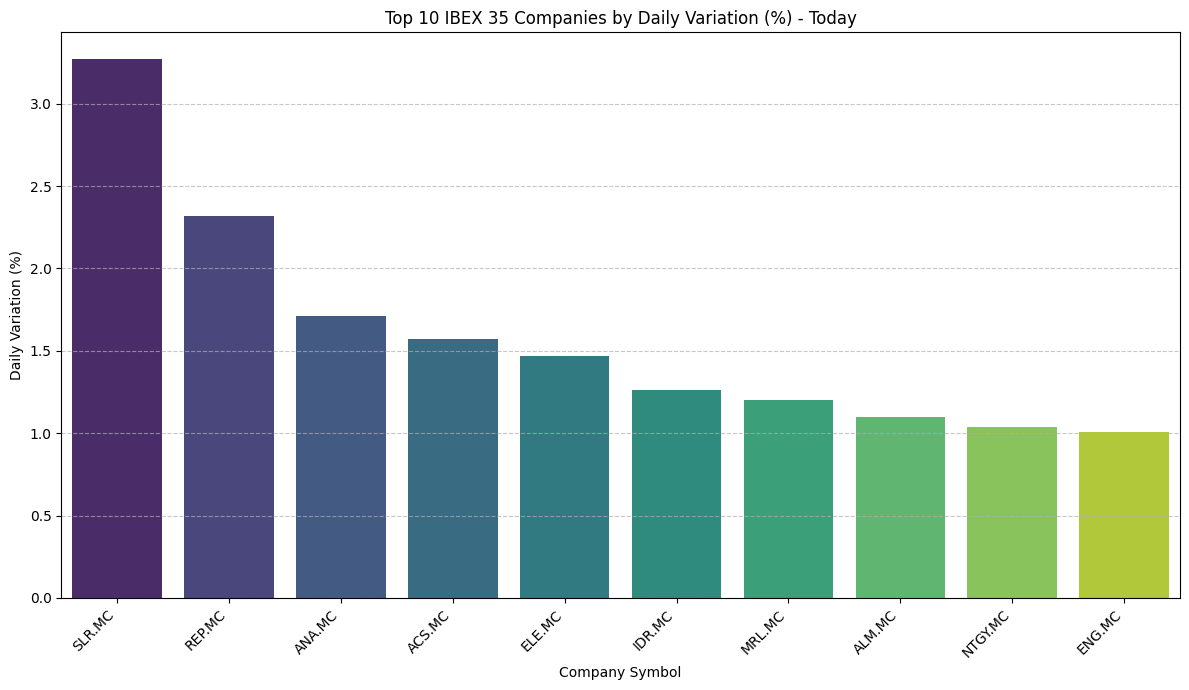

/tmp/ipykernel_15172/2186306914.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='_id', y='average_volatility', data=df_sector_volatility, palette='plasma')


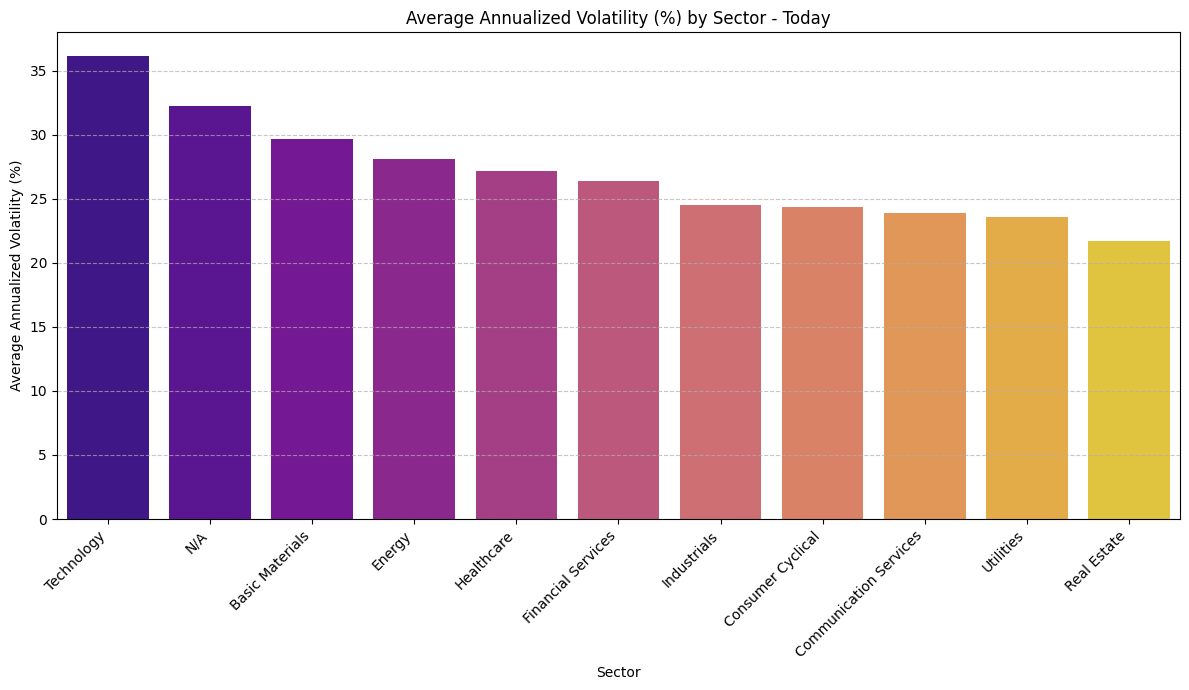

Visualizations generated successfully.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we have a DataFrame with today's data for plotting
# If df_today is empty, fetch all documents from today again
if 'df_today' not in locals() or df_today.empty:
    df_today = pd.DataFrame(list(collection.find({
        "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}
    })))

if df_today.empty:
    print("No data available from today's snapshot for visualizations.")
else:
    print("\nGenerating visualizations...")

    # Plot 1: Top 10 companies by daily variation
    plt.figure(figsize=(12, 7))
    top_10_daily_var = df_today.sort_values(by='daily_variation_pct', ascending=False).head(10)
    sns.barplot(x='symbol', y='daily_variation_pct', data=top_10_daily_var, palette='viridis')
    plt.title('Top 10 IBEX 35 Companies by Daily Variation (%) - Today')
    plt.xlabel('Company Symbol')
    plt.ylabel('Daily Variation (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot 2: Average volatility by sector
    # Ensure df_sector_volatility is available, if not, re-run aggregation
    if 'df_sector_volatility' not in locals() or df_sector_volatility.empty:
        sector_volatility_data = list(collection.aggregate(pipeline)) # Use the pipeline defined earlier
        df_sector_volatility = pd.DataFrame(sector_volatility_data)

    if not df_sector_volatility.empty:
        plt.figure(figsize=(12, 7))
        sns.barplot(x='_id', y='average_volatility', data=df_sector_volatility, palette='plasma')
        plt.title('Average Annualized Volatility (%) by Sector - Today')
        plt.xlabel('Sector')
        plt.ylabel('Average Annualized Volatility (%)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("No sector volatility data for visualization.")

    print("Visualizations generated successfully.")